<div align="left" style="background-color: #008080; padding: 20px 10px;">
<h3><b>IDEAS - Institute of Data Engineering, Analytics and Science Foundation</b></h3>
<p>Spring Internship Program 2026</p>
<hr style="width:100%;">
<h3><b>Project Title:</b> Imagedata Augmentation and Image Classification</h3>
<h4>Project Notebook</h4>

<blockquote style="border-left: 4px solid #4285F4; padding-left: 15px;">
  <strong>Created by:</strong> Koustab Ghosh<sup>1</sup> & Sujoy Kumar Biswas<sup>2</sup><br>
  <strong>Designation:</strong>
  <ol style="margin-top: 5px; padding-left: 20px; font-size: 0.9em;">
    <li>Researcher, IDEAS-TIH, Indian Statistical Institute, Kolkata</li>
    <li>Head of Research & Innovation, IDEAS-TIH, Indian Statistical Institute, Kolkata</li>
  </ol>
</blockquote>
<hr style="width:100%;">
</div>

### Question 1: Import Libraries and Load Image (5 Marks)

Import `numpy` as `np` and `cv2`. Download the image 'moon-pexels-frank-cone.jpg' from https://drive.google.com/drive/folders/1TeLp4U4NsXCSgClbF7ODBsaLKpHSWeQr?usp=sharing and load it into a variable named `original_image` using OpenCV. Print the shape of the loaded image.

**Hint:** Use `cv2.imread()` to load the image and `.shape` to get its dimensions.

**Expected Output:** A tuple representing the shape of the image (height, width, channels).

In [1]:
import numpy as np
import cv2
import gdown

file_id = '1oxjO8sVvjO7552kciqyIPz9_h2KiGupq'
output_path = 'moon-pexels-frank-cone.jpg'

gdown.download(id=file_id, output=output_path, quiet=False)

original_image = cv2.imread(output_path)

if original_image is not None:
    print(original_image.shape)
else:
    print("Error: Image could not be loaded. Check if the file was downloaded correctly.")


Downloading...
From: https://drive.google.com/uc?id=1oxjO8sVvjO7552kciqyIPz9_h2KiGupq
To: /content/moon-pexels-frank-cone.jpg
100%|██████████| 42.9k/42.9k [00:00<00:00, 49.6MB/s]

(800, 640, 3)


### Question 2: Convert to Grayscale (5 Marks)

Convert the `original_image` to grayscale using OpenCV's `cvtColor` function. Store the result in a variable named `grayscale_image`. Print the shape of the new grayscale image.

**Hint:** Use `cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)`. The shape of the grayscale image will have two dimensions instead of three.

**Expected Output:** A tuple representing the shape of the grayscale image (height, width).

In [2]:
grayscale_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)

print(grayscale_image.shape)


(800, 640)


### Question 3: Save the Grayscale Image (5 Marks)

Save your `grayscale_image` to a file named `graymoon.jpg`.

**Hint:** Use the `cv2.imwrite('filename.jpg', image_variable)` function.

**Expected Output:** No direct output, but a file named `graymoon.jpg` will be created in your workspace.

In [3]:
cv2.imwrite('graymoon.jpg', grayscale_image)


True

### Question 4: Shift the Image (10 Marks)

Create a transformation matrix `M` to shift the `original_image` 50 pixels to the right and 100 pixels down. Apply this transformation using `cv2.warpAffine` and store the result in `shifted_image`. Print the shape of `shifted_image`.

**Hint:** The matrix `M` will be a 2x3 NumPy float32 array: `np.float32([[1, 0, 50], [0, 1, 100]])`. The output shape should be the same as the original image.

**Expected Output:** The shape of the shifted image, which will be identical to the original image's shape.

In [4]:
M = np.float32([[1, 0, 50],
                [0, 1, 100]])

height, width = original_image.shape[:2]

shifted_image = cv2.warpAffine(original_image, M, (width, height))

print(shifted_image.shape)


(800, 640, 3)


### Question 5: Resize the Image (10 Marks)

Resize the `original_image` to be 150 pixels wide and 100 pixels tall. Store the result in a variable named `resized_image` and print its new shape.

**Hint:** Use the `cv2.resize()` function. The desired size is passed as a tuple `(width, height)`.

**Expected Output:** The tuple `(100, 150, 3)` representing the new shape (height, width, channels).

In [5]:
resized_image = cv2.resize(original_image, (150, 100))

print(resized_image.shape)


(100, 150, 3)


### Question 6: Rotate the Image (10 Marks)

Rotate the `original_image` by 90 degrees counter-clockwise around its center. Store the result in a variable named `rotated_image` and print its shape.

**Hint:** First, get the image dimensions. Then, create a rotation matrix using `cv2.getRotationMatrix2D(center, angle, scale)`. Finally, apply it with `cv2.warpAffine`.

**Expected Output:** The shape of the rotated image. Note that the height and width will be swapped compared to the original.

In [6]:
height, width = original_image.shape[:2]

center = (width // 2, height // 2)

rotation_matrix = cv2.getRotationMatrix2D(center, 90, 1.0)

rotated_image = cv2.warpAffine(original_image, rotation_matrix, (height, width))

print(rotated_image.shape)


(640, 800, 3)


### Question 7: Download and Unzip Cat/Dog Data (10 Marks)

Download the Cat and Dog image dataset from the following link https://s3.amazonaws.com/content.udacity-data.com/nd089/Cat_Dog_data.zip and then unzip it. This will create a 'Cat_Dog_data' directory.

**Hint:** Download and unzip to extract the files.

**Expected Output:** No direct Python output, but the cell's log should show the download and extraction process completing successfully.

In [7]:
import requests
import zipfile # Import zipfile for unzipping
import os

url = "https://s3.amazonaws.com/content.udacity-data.com/nd089/Cat_Dog_data.zip"
zip_path = "Cat_Dog_data.zip"
output_dir = "Cat_Dog_data"

# Download the zip file
response = requests.get(url)
with open(zip_path, "wb") as f:
    f.write(response.content)

print("Dataset downloaded successfully.")

# Unzip the downloaded file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

print(f"Dataset unzipped to {output_dir}/")

# Optionally, remove the zip file after extraction
os.remove(zip_path)
print(f"Removed {zip_path}")

Dataset downloaded successfully.
Dataset unzipped to Cat_Dog_data/
Removed Cat_Dog_data.zip


### Question 8: Create an Image Transform Pipeline (15 Marks)

Import `torch` and necessary modules from `torchvision`. Define a transform pipeline named `train_transform` that resizes images to 255x255, randomly flips them horizontally, and then converts them to a tensor.

**Hint:** Use `transforms.Compose()` with a list containing `transforms.Resize()`, `transforms.RandomHorizontalFlip()`, and `transforms.ToTensor()`.

**Expected Output:** No output, but the `train_transform` object should be created successfully.

In [8]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.Resize((255, 255)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])


### Question 9: Create an ImageFolder Dataset (15 Marks)

Create an `ImageFolder` dataset named `train_dataset` from the `'Cat_Dog_data/train'` directory, applying the `train_transform` pipeline you just created. Print the total number of images found in the dataset.

**Hint:** Use `datasets.ImageFolder(data_dir, transform=your_transform)`. The number of images is the length of the dataset object, which you can get with `len()`.

**Expected Output:** A printout of the number of images in the training dataset.

In [9]:
train_data_dir = "Cat_Dog_data/Cat_Dog_data/train"

train_dataset = datasets.ImageFolder(
    root=train_data_dir,
    transform=train_transform
)

print("Total training images:", len(train_dataset))


Total training images: 22500


### Question 10: Create a DataLoader (15 Marks)

Create a `DataLoader` named `train_loader` from the `train_dataset`. Set the `batch_size` to 64 and `shuffle` to True. Then, retrieve one batch of images and labels from the loader and print the shape of the images tensor and the labels tensor.

**Hint:** Use `torch.utils.data.DataLoader()`. To get one batch, use `images, labels = next(iter(train_loader))`. Print `images.shape` and `labels.shape`.

**Expected Output:** Two printed tuples representing the shapes of the image batch and the label batch.

In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)


Image batch shape: torch.Size([64, 3, 255, 255])
Label batch shape: torch.Size([64])


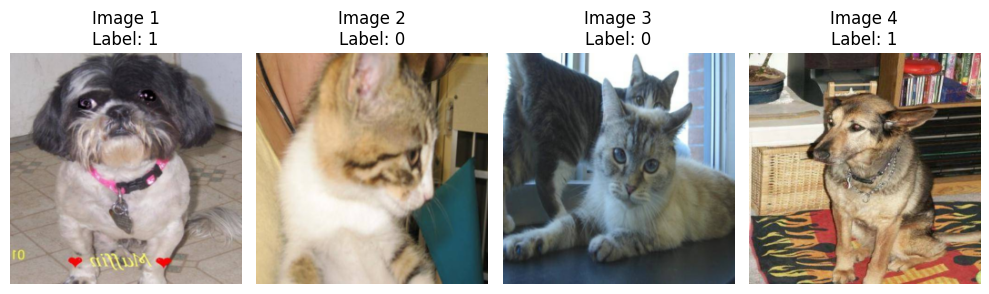

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Visualize the first few images from the batch
num_images_to_show = 4

plt.figure(figsize=(10, 10))
for i in range(num_images_to_show):
    # Get the i-th image from the batch
    image_tensor = images[i]

    # Convert the PyTorch tensor to a NumPy array
    # Permute the dimensions from (C, H, W) to (H, W, C) for matplotlib
    # Multiply by 255 to scale back to 0-255 range and convert to uint8
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy() * 255
    image_np = image_np.astype(np.uint8)

    # Get the corresponding label (if needed for title)
    label = labels[i].item()

    plt.subplot(1, num_images_to_show, i + 1) # Arrange in a row
    plt.imshow(image_np)
    plt.title(f"Image {i+1}\nLabel: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()
